In [ ]:
# Libraries 
import numpy as np

# Data Exploration


## SmartSeq

#### MCF 7

As mentioned above, the first steps are quite standard. We first look at the meta data. It is a great start for getting familiar with the dataset. It tells us important details about the structure that will be key later on in our research. In our case most of the metadata is simply put a breakdown of the column names of the SmartSeq MCF7 database (where each one represents a different cell) with some aditional information that may not be included in the name. In the metadata, each row represents a different cell while each column corresponds with a different feature that tells us for instance the condition of the cell, its position etc. 

In [9]:
print("Dataframe dimensions:", np.shape(df_SSMCF7_meta))  # df_adata = cells × genes
df_SSMCF7_meta.head(5)

Dataframe dimensions: (383, 8)


,Cell Line,Lane,Pos,Condition,Hours,Cell name,PreprocessingTag,ProcessingComments
Filename,,,,,,,,
output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam,MCF7,output.STAR.1,A10,Hypo,72,S28,Aligned.sortedByCoord.out.bam,"""STAR,FeatureCounts"""
output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoord.out.bam,MCF7,output.STAR.1,A11,Hypo,72,S29,Aligned.sortedByCoord.out.bam,"""STAR,FeatureCounts"""
output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam,MCF7,output.STAR.1,A12,Hypo,72,S30,Aligned.sortedByCoord.out.bam,"""STAR,FeatureCounts"""
output.STAR.1_A1_Norm_S1_Aligned.sortedByCoord.out.bam,MCF7,output.STAR.1,A1,Norm,72,S1,Aligned.sortedByCoord.out.bam,"""STAR,FeatureCounts"""
output.STAR.1_A2_Norm_S2_Aligned.sortedByCoord.out.bam,MCF7,output.STAR.1,A2,Norm,72,S2,Aligned.sortedByCoord.out.bam,"""STAR,FeatureCounts"""


Next we look at the actual dataset. In this part we will explore without making any actual changes to the data. This is a crucial step to help us understand what we are dealing with and to help us figure out the necessary steps to take in the preprocessing phase and as a whole in the project. By printing the first 10 rows we see that each column is a different cell, as mentioned above, while each row represents a different gene. The numerical value for each gene in a given cell is the gene expression level or simply how much of that gene is in the cell. It is important to note that, only from such a small section of our database, we already see intriguing details. First, the dataset seems to be quite sparse with a lot of 0s (i.e. a lot of unexpressed genes). Another thing that comes to our attention is the fact that some genes have expression levels that are on average higher than other genes. This might pose some issues in certain approaches like PCA so a normalization might be required. 

In [11]:
print("Dataframe dimensions:", np.shape(df_SSMCF7))
df_SSMCF7.head(10)

Dataframe dimensions: (22934, 383)


,"""output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A1_Norm_S1_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A2_Norm_S2_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A3_Norm_S3_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A4_Norm_S4_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A5_Norm_S5_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A6_Norm_S6_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A7_Hypo_S25_Aligned.sortedByCoord.out.bam""",...,"""output.STAR.4_H14_Hypo_S383_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H1_Norm_S355_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H2_Norm_S356_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H3_Norm_S357_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H4_Norm_S358_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H5_Norm_S359_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H6_Norm_S360_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H7_Hypo_S379_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H8_Hypo_S380_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H9_Hypo_S381_Aligned.sortedByCoord.out.bam"""
"""WASH7P""",0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,1
"""MIR6859-1""",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"""WASH9P""",1,0,0,0,0,1,10,1,0,0,...,1,1,0,0,0,0,1,1,4,5
"""OR4F29""",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
"""MTND1P23""",0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
"""MTND2P28""",2,0,1,0,0,1,3,6,16,0,...,0,4,45,2,1,0,2,7,29,5
"""MTCO1P12""",2,0,1,0,0,3,10,5,5,0,...,1,7,35,4,0,1,5,0,4,3
"""MTCO2P12""",0,0,1,0,0,0,1,2,1,0,...,0,1,1,1,0,0,5,0,0,0
"""MTATP8P1""",0,0,0,0,0,0,0,0,1,0,...,0,0,2,0,0,0,0,0,0,0
"""MTATP6P1""",29,0,12,7,68,203,691,206,766,4,...,50,294,1662,214,131,49,370,33,228,71


Two peculiar things also are that our samples are the columns while the futures are rows. Of course there is nothing wrong with that but should be kept in mind in order to prevent any confusion or issues with methods that expect the "standard" orientation. Similarly, we see that we have a much higher feature count than the sample size so dimensionality reduction would most likely benefit our database in order to be able to train a model more effectively. 

In [13]:
df_SSMCF7.shape

(22934, 383)

Next we proceed by looking at the columns. We confirm that each column represents a different cell with some information presented in the name. We also look at the indices, which again show us that each row is a different gene. 

We continue by looking at the details of the databse. We observe that different cells and different genes have quite different means of expression and standard deviations. This would suggest that normalization, standardization and log transform on the data could make models perform better. 

In [18]:
df_SSMCF7.describe()

,"""output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A1_Norm_S1_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A2_Norm_S2_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A3_Norm_S3_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A4_Norm_S4_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A5_Norm_S5_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A6_Norm_S6_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A7_Hypo_S25_Aligned.sortedByCoord.out.bam""",...,"""output.STAR.4_H14_Hypo_S383_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H1_Norm_S355_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H2_Norm_S356_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H3_Norm_S357_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H4_Norm_S358_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H5_Norm_S359_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H6_Norm_S360_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H7_Hypo_S379_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H8_Hypo_S380_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H9_Hypo_S381_Aligned.sortedByCoord.out.bam"""
count,22934.000000,22934.000000,22934.000000,22934.000000,22934.000000,22934.000000,22934.000000,22934.000000,22934.000000,22934.000000,...,22934.000000,22934.000000,22934.000000,22934.000000,22934.000000,22934.000000,22934.000000,22934.000000,22934.000000,22934.000000
mean,40.817651,0.012253,86.442400,1.024636,14.531351,56.213613,75.397183,62.767725,67.396747,2.240734,...,17.362562,42.080230,34.692422,32.735284,21.992718,17.439391,49.242784,61.545609,68.289352,62.851400
std,465.709940,0.207726,1036.572689,6.097362,123.800530,503.599145,430.471519,520.167576,459.689019,25.449630,...,193.153757,256.775704,679.960908,300.291051,153.441647,198.179666,359.337479,540.847355,636.892085,785.670341
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,17.000000,0.000000,5.000000,0.000000,7.000000,23.000000,39.000000,35.000000,38.000000,1.000000,...,9.000000,30.000000,0.000000,17.000000,12.000000,9.000000,27.000000,30.000000,38.000000,33.000000
max,46744.000000,14.000000,82047.000000,289.000000,10582.000000,46856.000000,29534.000000,50972.000000,36236.000000,1707.000000,...,17800.000000,23355.000000,81952.000000,29540.000000,12149.000000,19285.000000,28021.000000,40708.000000,46261.000000,68790.000000


In [19]:
df_SSMCF7.T.describe()

,"""WASH7P""","""MIR6859-1""","""WASH9P""","""OR4F29""","""MTND1P23""","""MTND2P28""","""MTCO1P12""","""MTCO2P12""","""MTATP8P1""","""MTATP6P1""",...,"""MT-TH""","""MT-TS2""","""MT-TL2""","""MT-ND5""","""MT-ND6""","""MT-TE""","""MT-CYB""","""MT-TT""","""MT-TP""","""MAFIP"""
count,383.000000,383.000000,383.000000,383.00000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,...,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.00000,383.000000,383.000000,383.000000
mean,0.133159,0.026110,1.344648,0.05483,0.049608,6.261097,4.681462,0.524804,0.073107,222.054830,...,1.060052,0.443864,3.146214,1016.477807,204.600522,5.049608,2374.97389,2.083551,5.626632,1.749347
std,0.618664,0.249286,2.244543,0.31477,0.229143,7.565749,6.232649,0.980857,0.298131,262.616874,...,1.990566,1.090827,4.265352,1009.444811,220.781927,6.644302,2920.39000,3.372714,7.511180,3.895204
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,23.000000,...,0.000000,0.000000,0.000000,172.000000,30.500000,0.000000,216.50000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.00000,0.000000,3.000000,2.000000,0.000000,0.000000,98.000000,...,0.000000,0.000000,1.000000,837.000000,152.000000,3.000000,785.00000,0.000000,3.000000,0.000000
75%,0.000000,0.000000,2.000000,0.00000,0.000000,10.000000,7.000000,1.000000,0.000000,370.500000,...,1.000000,0.000000,5.000000,1549.000000,294.000000,7.000000,4059.00000,3.000000,8.000000,2.000000
max,9.000000,4.000000,20.000000,3.00000,2.000000,45.000000,36.000000,6.000000,2.000000,1662.000000,...,15.000000,8.000000,22.000000,8115.000000,2002.000000,46.000000,16026.00000,22.000000,56.000000,32.000000


In this next step, we check if all of our datatypes are numeric. In our case they are but if they were not we would have had to take extra steps in order to get our data ready for analysys, pca, and further training. 

In [21]:
print(df_SSMCF7.dtypes)

all_numeric_SSMCF7 = df_SSMCF7.applymap(np.isreal).all().all()
print("All values are numeric:", all_numeric_SSMCF7)

obj_cols = df_SSMCF7.select_dtypes(include="object").columns
print("Columns with object dtype:", obj_cols.tolist())
for col in obj_cols:
    # rows that can’t be parsed as numbers
    bad = df_SSMCF7.loc[
        pd.to_numeric(df_SSMCF7[col], errors="coerce").isna() &
        df_SSMCF7[col].notna(),
        col
    ]
    print(f"\n{col}  –  offending values and counts:")
    print(bad.value_counts().head(10))

"output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam"    int64
"output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoord.out.bam"    int64
"output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam"    int64
"output.STAR.1_A1_Norm_S1_Aligned.sortedByCoord.out.bam"      int64
"output.STAR.1_A2_Norm_S2_Aligned.sortedByCoord.out.bam"      int64
                                                              ...  
"output.STAR.4_H5_Norm_S359_Aligned.sortedByCoord.out.bam"    int64
"output.STAR.4_H6_Norm_S360_Aligned.sortedByCoord.out.bam"    int64
"output.STAR.4_H7_Hypo_S379_Aligned.sortedByCoord.out.bam"    int64
"output.STAR.4_H8_Hypo_S380_Aligned.sortedByCoord.out.bam"    int64
"output.STAR.4_H9_Hypo_S381_Aligned.sortedByCoord.out.bam"    int64
Length: 383, dtype: object


/var/folders/f8/0hzmswyj0sn232kss0n40r_80000gn/T/ipykernel_3997/3578250951.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  all_numeric_SSMCF7 = df_SSMCF7.applymap(np.isreal).all().all()


All values are numeric: True
Columns with object dtype: []


Next, we check for missing values. If such exist we may need to drop either the gene or the sample or use some other mothod to deal with the null. Thankfully in this case there are no missing values. 

In [23]:
missing_total_SSMCF7 = df_SSMCF7.isna().sum().sum()
print(f"Total missing values in the dataset: {missing_total_SSMCF7}")

Total missing values in the dataset: 0


Below, we check for outliers in both the features and the samples. In the features case we plot the variance of the genes and see a great spike at around 0 and a long tail to the right. This confirms that our data is sparse and that many genes are for "housekeeping" and don't change a lot, which in general is to be expected when dealing with RNA, but the long tail to the right suggests that few genes have extreamly high variance. It could either be noise or carry significant information. We also plot the same thing on the log scale to gain more clarity on the distribution. Likely the low variable genes can be safely discarded as they would not provide any significant insight and dependency and we can essentialy keep the "outliers" (i.e the genes with higher variance) as they could be crucial for our classification problem later on. 

<Axes: ylabel='Count'>

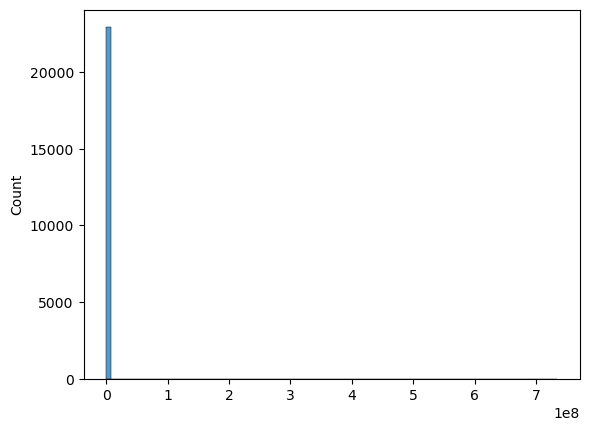

In [25]:
# Variance per gene
gene_var_SSMCF7 = df_SSMCF7.var(axis=1)
sns.histplot(gene_var_SSMCF7, bins=100)

<Axes: ylabel='Count'>

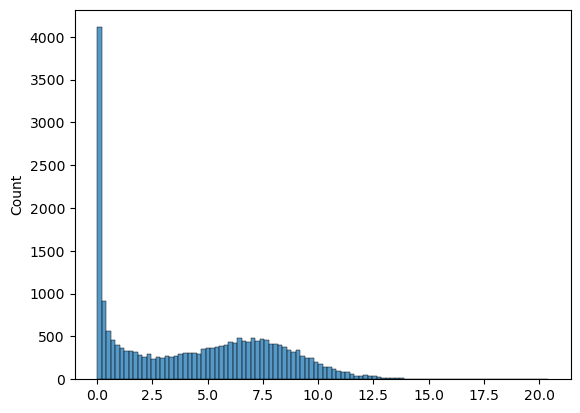

In [26]:
sns.histplot(np.log1p(gene_var_SSMCF7), bins=100)

When plotting the total reads we see that the majority is clustered around 1 million with a few outliers around 2 million. They are likely still valid just with deeper sequenccing. On the left side however we see a big spike around 0. These are the cells that have less than 100 000 reads and hence likely low quallity. We will deal with them in the preprocessing. Additionally, we also plot the mitochondrial percentage of cells and the numbers of expressed genes. These three plots will give us a good idea of important distributions, helping us figure out the cutoffs for certain samples that may be of low qallity. In the threee cases we see some tails that we could cut off in order to remove outliers and cells that are of low quallity. 

/var/folders/f8/0hzmswyj0sn232kss0n40r_80000gn/T/ipykernel_3997/3799926608.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/var/folders/f8/0hzmswyj0sn232kss0n40r_80000gn/T/ipykernel_3997/3799926608.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()
/var/folders/f8/0hzmswyj0sn232kss0n40r_80000gn/T/ipykernel_3997/3799926608.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()


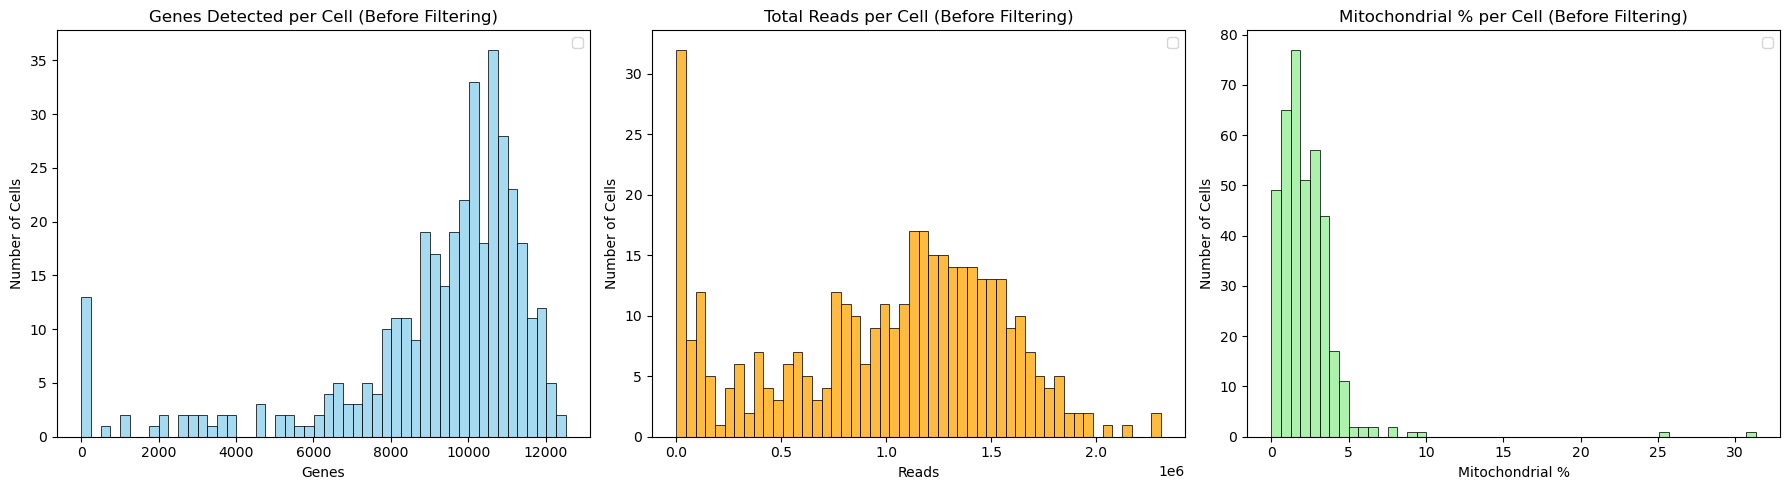

In [28]:
# ---- Calculate QC Metrics Before Filtering ----
genes_per_cell_SSMCF7 = (df_SSMCF7 > 0).sum(axis=0)
total_reads_per_cell_SSMCF7 = df_SSMCF7.sum(axis=0)

# Detect mitochondrial genes
clean_index_SSMCF7 = df_SSMCF7.index.str.replace('"', '').str.upper()
mito_genes_SSMCF7 = clean_index_SSMCF7.str.startswith("MT")
mito_reads_per_cell_SSMCF7 = df_SSMCF7.loc[mito_genes_SSMCF7].sum(axis=0)
mito_percent_per_cell_SSMCF7 = mito_reads_per_cell_SSMCF7 / total_reads_per_cell_SSMCF7 * 100

# ---- Plotting ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Genes per cell
sns.histplot(genes_per_cell_SSMCF7, bins=50, ax=axes[0], color='skyblue')
axes[0].set_title("Genes Detected per Cell (Before Filtering)")
axes[0].set_xlabel("Genes")
axes[0].set_ylabel("Number of Cells")
axes[0].legend()

# Total reads per cell
sns.histplot(total_reads_per_cell_SSMCF7, bins=50, ax=axes[1], color='orange')
axes[1].set_title("Total Reads per Cell (Before Filtering)")
axes[1].set_xlabel("Reads")
axes[1].set_ylabel("Number of Cells")
axes[1].legend()

# Mitochondrial percentage
sns.histplot(mito_percent_per_cell_SSMCF7, bins=50, ax=axes[2], color='lightgreen')
axes[2].set_title("Mitochondrial % per Cell (Before Filtering)")
axes[2].set_xlabel("Mitochondrial %")
axes[2].set_ylabel("Number of Cells")
axes[2].legend()

plt.tight_layout()
plt.show()

We can further check if our data is normalised with a simple plot. We select only some of the samples but that will be enough to show us that our data is not normalised. This is something we might want to change as even if two cells express the same genes at the same true biological level, one might appear to have more expression simply because it was sequenced more deeply. Without normalization, you'd mistake technical differences for biological ones.

Also we check that the genes are not normalized and since they are our features, genes that naturally have higher expression values might dominate certain algorithms and prevent us from discovering dependencies on less expressed features. 

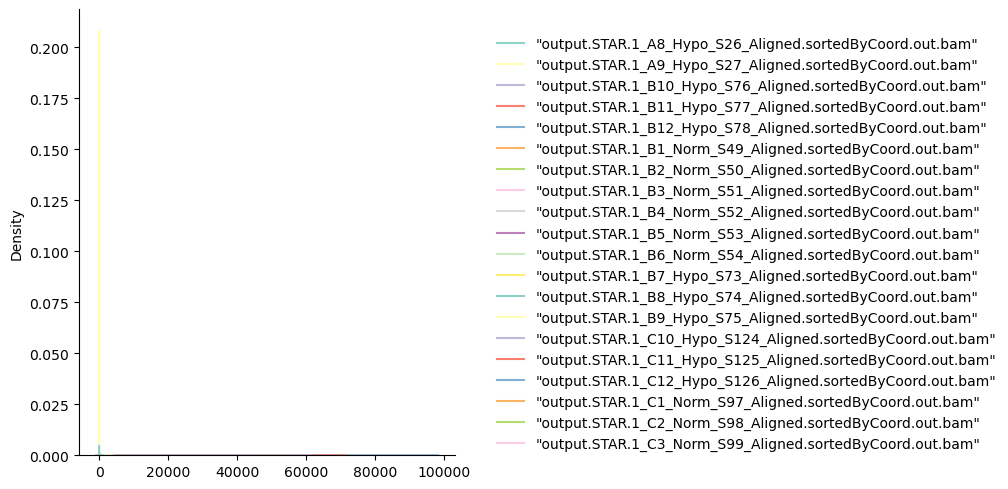

In [30]:
df_small_SSMCF7 = df_SSMCF7.iloc[:, 10:30]  
sns.displot(data=df_small_SSMCF7,palette="Set3",kind="kde", bw_adjust=2)

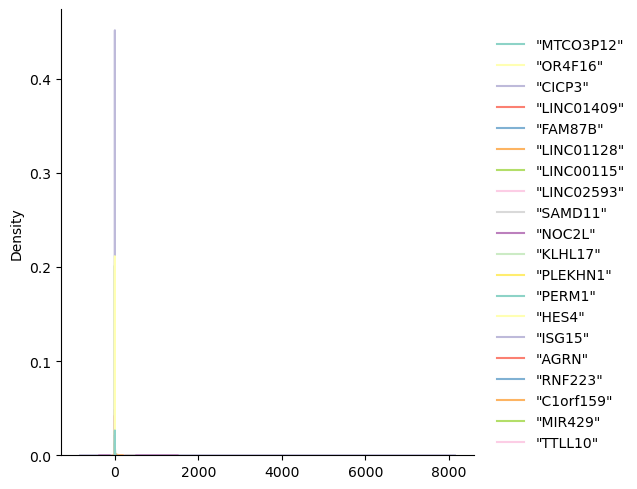

In [31]:
df_small_SSMCF7 = df_SSMCF7.T.iloc[:, 10:30]  
sns.displot(data=df_small_SSMCF7,palette="Set3",kind="kde", bw_adjust=2)

We can also look for ourliers through the IQR. This gives us the spread of expression values within each cell. The issue is that the dataset is quite sparse so the genes that actually carry information for the cells are the ones that have values different from 0, but since many of the genes have a value 0, the "flagged" outliers are actually the genes with higher values (i.e exactly the information carrying geneses). We will bump into the same issue in the case of the Smartseq HCC1806 database below. 

In [33]:
Q1 = df_SSMCF7.quantile(0.25, axis=0)  # Per cell (column)
Q3 = df_SSMCF7.quantile(0.75, axis=0)  # Per cell
IQR = Q3 - Q1    
print(IQR)

"output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam"    17.0
"output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoord.out.bam"     0.0
"output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam"     5.0
"output.STAR.1_A1_Norm_S1_Aligned.sortedByCoord.out.bam"       0.0
"output.STAR.1_A2_Norm_S2_Aligned.sortedByCoord.out.bam"       7.0
                                                              ... 
"output.STAR.4_H5_Norm_S359_Aligned.sortedByCoord.out.bam"     9.0
"output.STAR.4_H6_Norm_S360_Aligned.sortedByCoord.out.bam"    27.0
"output.STAR.4_H7_Hypo_S379_Aligned.sortedByCoord.out.bam"    30.0
"output.STAR.4_H8_Hypo_S380_Aligned.sortedByCoord.out.bam"    38.0
"output.STAR.4_H9_Hypo_S381_Aligned.sortedByCoord.out.bam"    33.0
Length: 383, dtype: float64


#### HCC 1806


We continue our exploration with the SmartSeq HCC1806 dataset. 

We can again start with the meta data. There is no need for further explanation as the sequencing method is the same as the MCF7 case discussed above and all of the observations about the structure of the metadata hold the same. The only difference is clearly the cell line which is now HCC1806. 

In [37]:
print("Dataframe dimensions:", np.shape(df_meta_SSHCC1806))
df_meta_SSHCC1806.head(5)

Dataframe dimensions: (243, 8)


,Cell Line,PCR Plate,Pos,Condition,Hours,Cell name,PreprocessingTag,ProcessingComments
Filename,,,,,,,,
output.STAR.PCRPlate1A10_Normoxia_S123_Aligned.sortedByCoord.out.bam,HCC1806,1,A10,Normo,24,S123,Aligned.sortedByCoord.out.bam,"""STAR,FeatureCounts"""
output.STAR.PCRPlate1A12_Normoxia_S26_Aligned.sortedByCoord.out.bam,HCC1806,1,A12,Normo,24,S26,Aligned.sortedByCoord.out.bam,"""STAR,FeatureCounts"""
output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.sortedByCoord.out.bam,HCC1806,1,A1,Hypo,24,S97,Aligned.sortedByCoord.out.bam,"""STAR,FeatureCounts"""
output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.sortedByCoord.out.bam,HCC1806,1,A2,Hypo,24,S104,Aligned.sortedByCoord.out.bam,"""STAR,FeatureCounts"""
output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sortedByCoord.out.bam,HCC1806,1,A3,Hypo,24,S4,Aligned.sortedByCoord.out.bam,"""STAR,FeatureCounts"""


We continue by taking a look at the database itself. Immediately, we notice the sparsity we saw before and the big differeence between the expression levels of some genes so a log transformation may again be needed. Also a normalization seems to be required in order to homogenise the read counts between the cells in order to prevent any biases due to cells that are sequenced deeper and have more reads. Again the structure is the one we have already familiarized ourselves with above, so there is not much more to be done.  

In [39]:
print("Dataframe dimensions:", np.shape(df_SSHCC1806))
df_SSHCC1806.head(10)

Dataframe dimensions: (23396, 243)


,"""output.STAR.PCRPlate1A10_Normoxia_S123_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A12_Normoxia_S26_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A4_Hypoxia_S8_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A5_Hypoxia_S108_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A6_Hypoxia_S11_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A7_Normoxia_S113_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A8_Normoxia_S119_Aligned.sortedByCoord.out.bam""",...,"""output.STAR.PCRPlate4G12_Normoxia_S243_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4G1_Hypoxia_S193_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4G2_Hypoxia_S198_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4G6_Hypoxia_S232_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4G7_Normoxia_S204_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H10_Normoxia_S210_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H11_Normoxia_S214_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H2_Hypoxia_S199_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H7_Normoxia_S205_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H9_Normoxia_S236_Aligned.sortedByCoord.out.bam"""
"""WASH7P""",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"""CICP27""",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"""DDX11L17""",0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"""WASH9P""",0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
"""OR4F29""",2,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"""MTND1P23""",250,424,11,63,27,81,305,82,46,177,...,205,113,47,27,35,146,37,83,47,249
"""MTND2P28""",54,100,0,16,3,1,70,8,5,10,...,27,35,8,4,4,47,6,30,7,38
"""MTCO1P12""",1740,2340,22,1020,303,587,2572,1004,443,779,...,639,790,644,386,297,961,372,1128,258,980
"""MTCO2P12""",6,5,0,3,0,0,1,5,0,2,...,1,2,0,1,1,1,0,4,1,0
"""MTATP8P1""",1,1,0,0,0,0,3,0,0,1,...,0,1,0,0,2,0,0,0,0,0


Looking at the shape or rather the dimensions of our data we see that they are not the same as in the SmartSeq MCF7 case. The sample is smaller at 243 cells while the features are more at 23396. 

In [41]:
df_SSHCC1806.shape

(23396, 243)

Again we look at the rows and the columns and the results are the same as in the Smartseq MCF7 case. 

Now we take a look at the details of the database. Again, the results are similar to the Smartseq MCF7 case.

In [46]:
df_SSHCC1806.describe()

,"""output.STAR.PCRPlate1A10_Normoxia_S123_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A12_Normoxia_S26_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A4_Hypoxia_S8_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A5_Hypoxia_S108_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A6_Hypoxia_S11_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A7_Normoxia_S113_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A8_Normoxia_S119_Aligned.sortedByCoord.out.bam""",...,"""output.STAR.PCRPlate4G12_Normoxia_S243_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4G1_Hypoxia_S193_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4G2_Hypoxia_S198_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4G6_Hypoxia_S232_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4G7_Normoxia_S204_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H10_Normoxia_S210_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H11_Normoxia_S214_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H2_Hypoxia_S199_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H7_Normoxia_S205_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H9_Normoxia_S236_Aligned.sortedByCoord.out.bam"""
count,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000,...,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000
mean,99.565695,207.678278,9.694734,150.689007,35.700504,47.088434,152.799453,135.869422,38.363908,45.512139,...,76.361771,105.566593,54.026116,29.763806,28.905411,104.740725,35.181569,108.197940,37.279962,76.303855
std,529.532443,981.107905,65.546050,976.936548,205.885369,545.367706,864.974182,870.729740,265.062493,366.704721,...,346.659348,536.881574,344.068304,186.721266,135.474736,444.773045,170.872090,589.082268,181.398951,369.090274
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
75%,51.000000,125.000000,5.000000,40.000000,22.000000,17.000000,81.000000,76.000000,22.000000,18.000000,...,56.000000,67.000000,29.000000,18.000000,19.000000,76.000000,24.000000,68.000000,22.000000,44.000000
max,35477.000000,69068.000000,6351.000000,70206.000000,17326.000000,47442.000000,43081.000000,62813.000000,30240.000000,35450.000000,...,19629.000000,30987.000000,21894.000000,13457.000000,11488.000000,33462.000000,15403.000000,34478.000000,10921.000000,28532.000000


In [47]:
df_SSHCC1806.T.describe()

,"""WASH7P""","""CICP27""","""DDX11L17""","""WASH9P""","""OR4F29""","""MTND1P23""","""MTND2P28""","""MTCO1P12""","""MTCO2P12""","""MTATP8P1""",...,"""MT-TH""","""MT-TS2""","""MT-TL2""","""MT-ND5""","""MT-ND6""","""MT-TE""","""MT-CYB""","""MT-TT""","""MT-TP""","""MAFIP"""
count,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,...,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,0.045267,0.119342,0.469136,0.255144,0.127572,117.930041,28.427984,904.308642,1.403292,0.378601,...,10.358025,5.930041,13.493827,2290.213992,386.901235,18.246914,2163.588477,20.613169,46.444444,3.897119
std,0.318195,0.594531,1.455282,0.818639,0.440910,103.038022,26.062662,654.520308,1.735003,0.747361,...,10.910199,7.040559,11.803967,1726.423259,309.276105,54.076514,1730.393947,22.224590,47.684223,4.736193
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,46.500000,8.000000,390.500000,0.000000,0.000000,...,2.000000,1.000000,4.000000,918.000000,138.500000,4.000000,947.500000,5.000000,14.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,94.000000,22.000000,790.000000,1.000000,0.000000,...,7.000000,4.000000,10.000000,1848.000000,320.000000,11.000000,1774.000000,14.000000,38.000000,2.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,157.000000,42.000000,1208.000000,2.000000,1.000000,...,14.000000,7.500000,20.000000,3172.000000,528.000000,20.000000,2927.000000,30.500000,64.500000,6.000000
max,3.000000,5.000000,12.000000,6.000000,4.000000,694.000000,120.000000,3569.000000,12.000000,4.000000,...,52.000000,43.000000,57.000000,8972.000000,1439.000000,804.000000,11383.000000,154.000000,409.000000,24.000000


Next, we check for missing values. Again, in this case everything is alright so we leave the dataset as it is for now. 

In [49]:
missing_total_SSHCC1806 = df_SSHCC1806.isna().sum().sum()
print(f"Total missing values in the dataset: {missing_total_SSHCC1806}")

Total missing values in the dataset: 0


Taking a look at the variance of the genes, again we see a great spike at around 0 and a long tail to the right. This spike sugests that a great majority of the genes are mainly sparse and or are "housekeeping" genes that are relatively constant among the cells. The same as in the previous dataset we may want to filter out such genes and leave the ones with higher variance as they would likely be the ones that would provide the best model. This way we only keep the most useful while simplifying the dataset and respectively our model.

<Axes: ylabel='Count'>

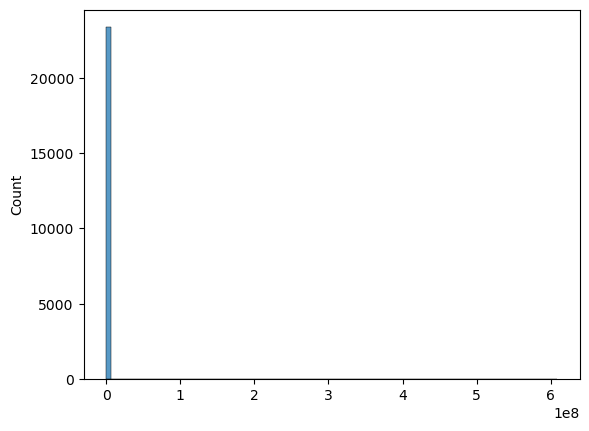

In [51]:
# Variance per gene
gene_var_SSHCC1806 = df_SSHCC1806.var(axis=1)
sns.histplot(gene_var_SSHCC1806, bins=100)

Just as above, a log plot would better show us the underlying distribution. Where we see a similar curve as before, that, disregarding the spike, starts off lower, raises and falls again with a long tail to the right. 

<Axes: ylabel='Count'>

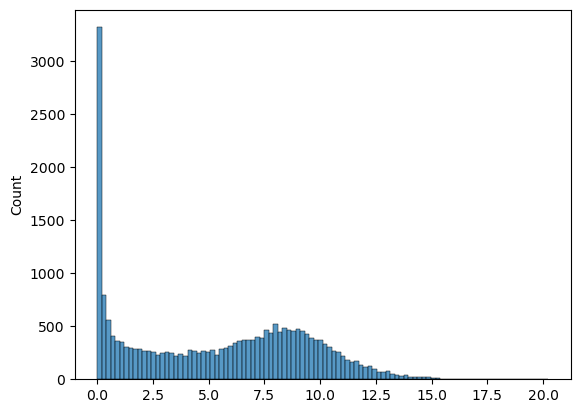

In [53]:
sns.histplot(np.log1p(gene_var_SSHCC1806), bins=100)

Moving on to the analysis of the total read counts, gene expression count and mitochondrial percentage of the cells, we notice that in this dataset when looking at the plots we see that the distribution of cells is such that there are much fewer cells with low gene expression counts and low read counts. In the latter there isn't a big spike arround 0, but spikes/clusters of cells at different read counts over 500 000. Lastly looking at the mitochondrial percentage, the situation seems to be similar to the former case. All the three plots suggest that in this case there are less cells of low quality that we would otherwise remove, a fact which may be attributed to technological advancements or better cell collection. This is a good sign as this dataset has less cells overall so we would like to keep as many of the cells as possible in order to get a well trained model. 

/var/folders/f8/0hzmswyj0sn232kss0n40r_80000gn/T/ipykernel_3997/694944192.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/var/folders/f8/0hzmswyj0sn232kss0n40r_80000gn/T/ipykernel_3997/694944192.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()
/var/folders/f8/0hzmswyj0sn232kss0n40r_80000gn/T/ipykernel_3997/694944192.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()


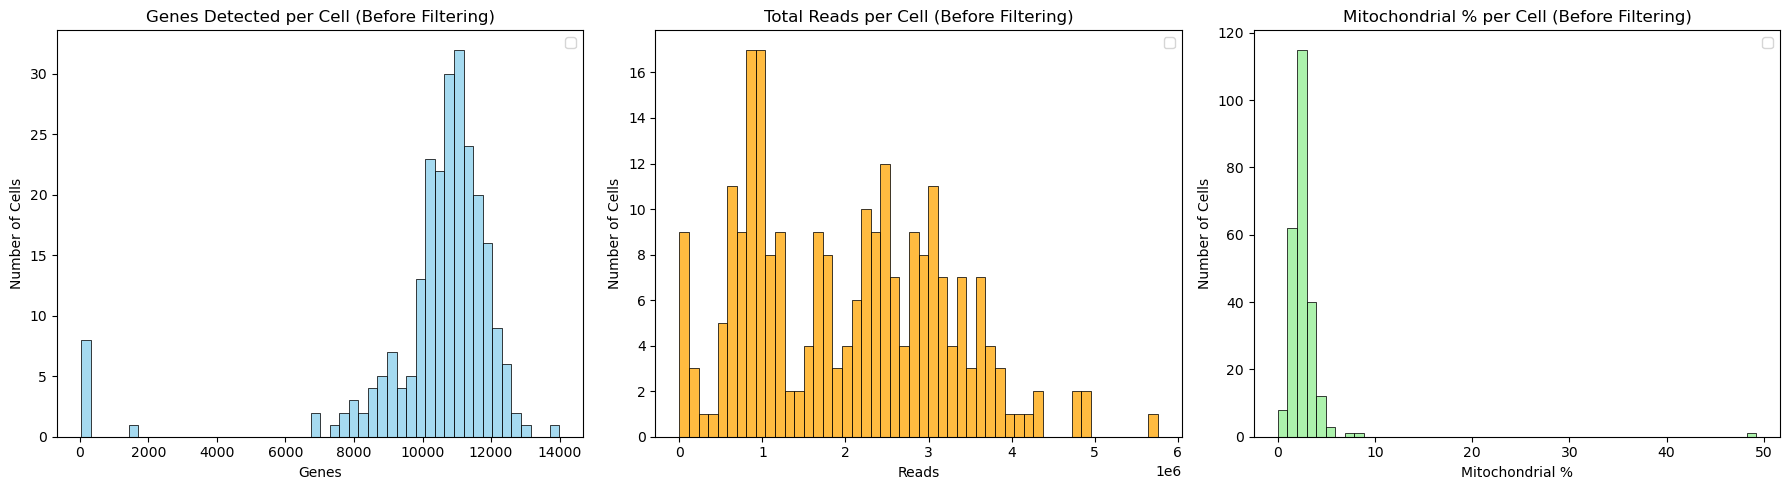

In [55]:
# ---- Calculate QC Metrics Before Filtering ----
genes_per_cell_SSHCC1806 = (df_SSHCC1806 > 0).sum(axis=0)
total_reads_per_cell_SSHCC1806 = df_SSHCC1806.sum(axis=0)

# Detect mitochondrial genes
clean_index_SSHCC1806 = df_SSHCC1806.index.str.replace('"', '').str.upper()
mito_genes_SSHCC1806 = clean_index_SSHCC1806.str.startswith("MT")
mito_reads_per_cell_SSHCC1806 = df_SSHCC1806.loc[mito_genes_SSHCC1806].sum(axis=0)
mito_percent_per_cell_SSHCC1806 = mito_reads_per_cell_SSHCC1806 / total_reads_per_cell_SSHCC1806 * 100

# ---- Plotting ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Genes per cell
sns.histplot(genes_per_cell_SSHCC1806, bins=50, ax=axes[0], color='skyblue')
axes[0].set_title("Genes Detected per Cell (Before Filtering)")
axes[0].set_xlabel("Genes")
axes[0].set_ylabel("Number of Cells")
axes[0].legend()

# Total reads per cell
sns.histplot(total_reads_per_cell_SSHCC1806, bins=50, ax=axes[1], color='orange')
axes[1].set_title("Total Reads per Cell (Before Filtering)")
axes[1].set_xlabel("Reads")
axes[1].set_ylabel("Number of Cells")
axes[1].legend()

# Mitochondrial percentage
sns.histplot(mito_percent_per_cell_SSHCC1806, bins=50, ax=axes[2], color='lightgreen')
axes[2].set_title("Mitochondrial % per Cell (Before Filtering)")
axes[2].set_xlabel("Mitochondrial %")
axes[2].set_ylabel("Number of Cells")
axes[2].legend()

plt.tight_layout()
plt.show()


We can also do plots that will visualize whether the data is normalized. Again it is clearly not, neither the samples nor the features which would lead to difficulties with models if left unchanged. 

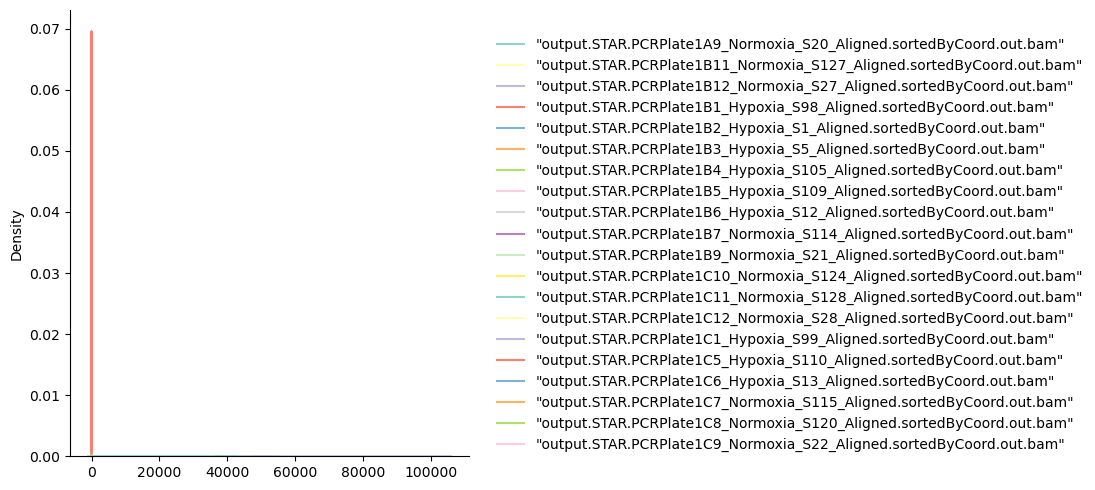

In [57]:
df_small_SSHCC1806 = df_SSHCC1806.iloc[:, 10:30]  
sns.displot(data=df_small_SSHCC1806,palette="Set3",kind="kde", bw_adjust=2)

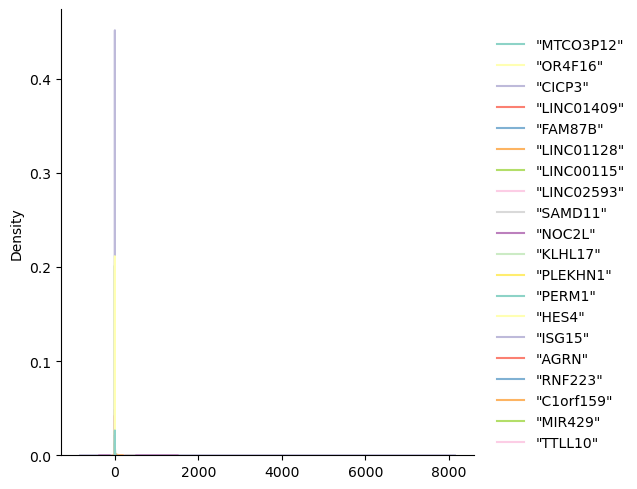

In [58]:
df_small_SSMCF7 = df_SSMCF7.T.iloc[:, 10:30]  
sns.displot(data=df_small_SSMCF7,palette="Set3",kind="kde", bw_adjust=2)

## DropSeq

It is important to note most of what is done below is similar to the steps above, so less explanation will be given.

#### MCF 7

Reading the dataset and showing the first 5 rows, we see that the overall expression counts per gene seem to be lower which is expected given the more shallow sequencing method. 

In [63]:
df_DSMCF7.head()

,"""AAAAACCTATCG_Normoxia""","""AAAACAACCCTA_Normoxia""","""AAAACACTCTCA_Normoxia""","""AAAACCAGGCAC_Normoxia""","""AAAACCTAGCTC_Normoxia""","""AAAACCTCCGGG_Normoxia""","""AAAACTCGTTGC_Normoxia""","""AAAAGAGCTCTC_Normoxia""","""AAAAGCTAGGCG_Normoxia""","""AAAATCGCATTT_Normoxia""",...,"""TTTTACAGGATC_Hypoxia""","""TTTTACCACGTA_Hypoxia""","""TTTTATGCTACG_Hypoxia""","""TTTTCCAGACGC_Hypoxia""","""TTTTCGCGCTCG_Hypoxia""","""TTTTCGCGTAGA_Hypoxia""","""TTTTCGTCCGCT_Hypoxia""","""TTTTCTCCGGCT_Hypoxia""","""TTTTGTTCAAAG_Hypoxia""","""TTTTTTGTATGT_Hypoxia"""
"""MALAT1""",1,3,3,6,4,5,1,13,3,3,...,0,2,1,0,1,0,1,0,0,4
"""MT-RNR2""",0,0,0,2,0,0,2,1,7,0,...,0,0,0,0,0,0,0,0,0,0
"""NEAT1""",0,0,0,0,0,2,0,1,2,0,...,0,0,0,0,0,0,0,0,0,0
"""H1-5""",0,0,0,0,0,2,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0
"""TFF1""",4,1,1,1,0,0,0,2,0,1,...,2,3,8,0,0,3,4,2,6,0


Here, we want to show the distribution of total different genes present in each cell by filtering the positive values from the dataframe.

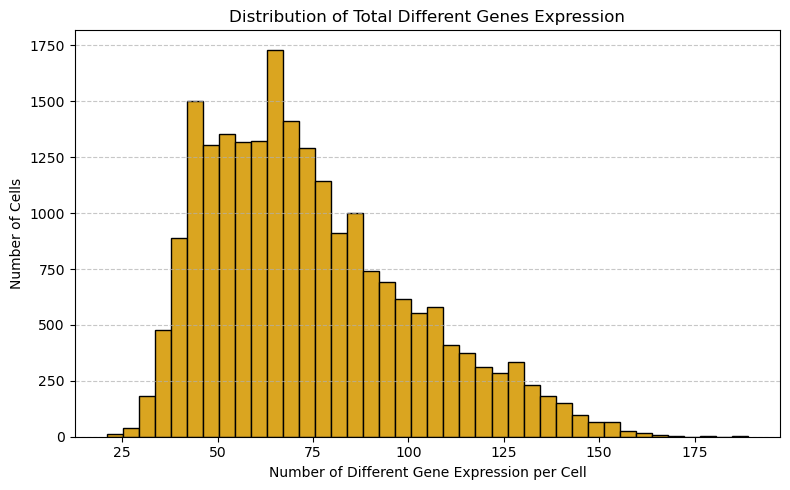

In [65]:
different_genes_per_cell = (df_DSMCF7 > 0).sum(axis=0)
plt.figure(figsize=(8, 5))
plt.hist(different_genes_per_cell, bins=40, color='goldenrod', edgecolor='black')
plt.xlabel("Number of Different Gene Expression per Cell")
plt.ylabel("Number of Cells")
plt.title("Distribution of Total Different Genes Expression")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Our dataset also needs to be checked for the total number of genes present in each cell, because filtering the cells that have less than 70 genes might help us in reducing our feature number.

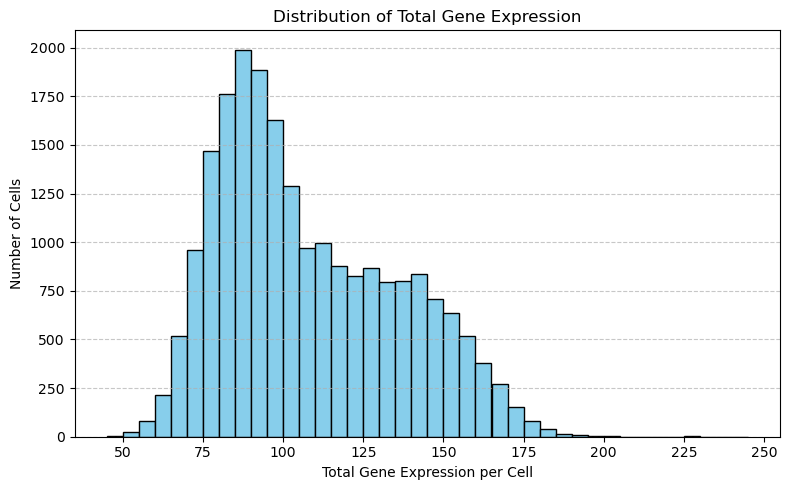

In [67]:
number_of_total_genes = df_DSMCF7.sum(axis=0)
plt.figure(figsize=(8, 5))
plt.hist(number_of_total_genes, bins=40, color='skyblue', edgecolor='black')
plt.xlabel("Total Gene Expression per Cell")
plt.ylabel("Number of Cells")
plt.title("Distribution of Total Gene Expression")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

At this point, we will also plot the histogram for the percentage of the Mitochondria present in each cell.

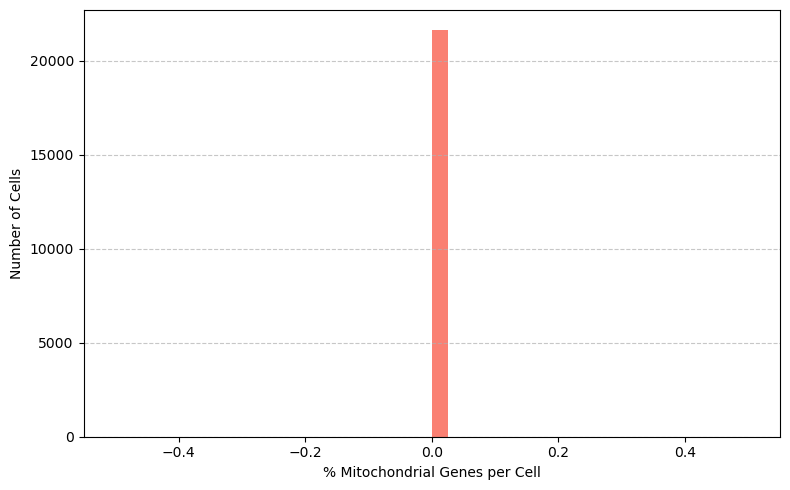

In [69]:
mt_genes = df_DSMCF7.index.str.startswith("MT-")
pct_mito = df_DSMCF7[mt_genes].sum(axis=0) / df_DSMCF7.sum(axis=0)
plt.figure(figsize=(8, 5))
plt.hist(pct_mito, bins=40, color='salmon')
plt.xlabel("% Mitochondrial Genes per Cell")
plt.ylabel("Number of Cells")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

We also want to discover whether there is a linear relationship between the number of different genes and the total number of genes in a cell.

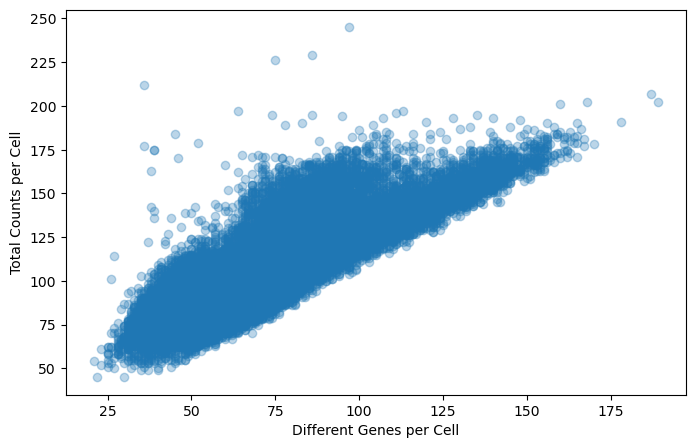

In [71]:
different_genes_per_cell = (df_DSMCF7 > 0).sum(axis=0)
number_of_total_genes = df_DSMCF7.sum(axis=0)
plt.figure(figsize=(8, 5))
plt.scatter(different_genes_per_cell, number_of_total_genes, alpha=0.3)
plt.xlabel("Different Genes per Cell")
plt.ylabel("Total Counts per Cell")
plt.show()

In this section, we want to look at the most and the least "popular" genes in our dataset.

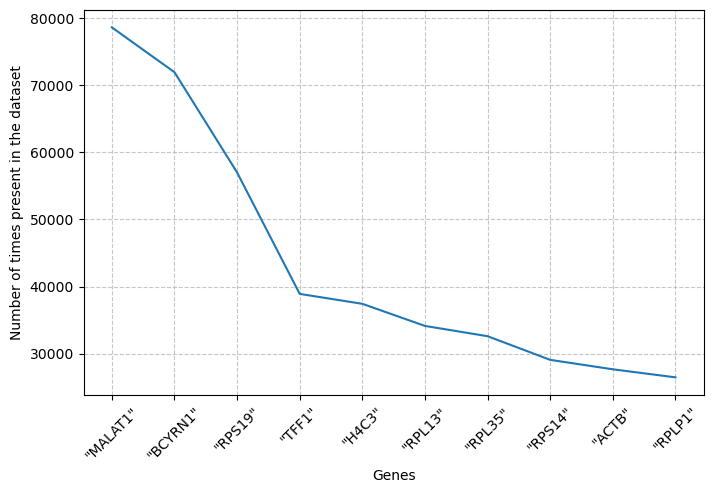

In [73]:
plt.figure(figsize=(8, 5))
most_frequent_genes = df_DSMCF7.sum(axis=1).sort_values(ascending=False).head(10)
plt.plot(most_frequent_genes)
plt.xticks(rotation=45)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel("Genes")
plt.ylabel("Number of times present in the dataset")
plt.show()

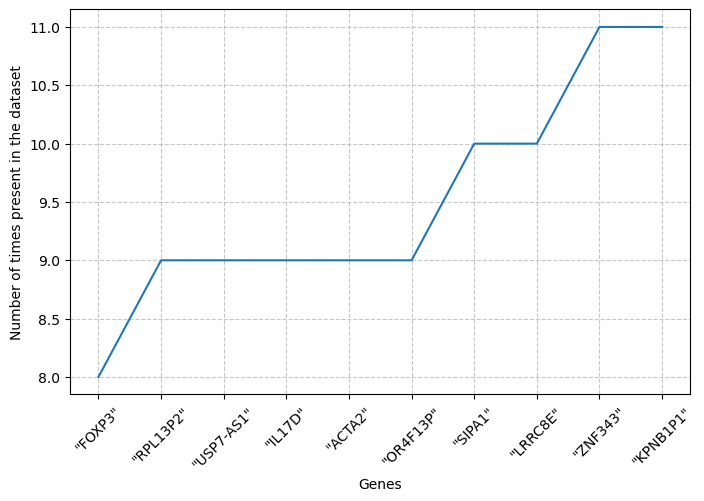

In [74]:
plt.figure(figsize=(8, 5))
most_frequent_genes = df_DSMCF7.sum(axis=1).sort_values(ascending=True).head(10)
plt.plot(most_frequent_genes)
plt.xticks(rotation=45)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel("Genes")
plt.ylabel("Number of times present in the dataset")
plt.show()

Proceeding, we will compute the variance of each gene and extract the ones with a variance lower than 1%

In [76]:
variance = df_DSMCF7.var(axis=1)

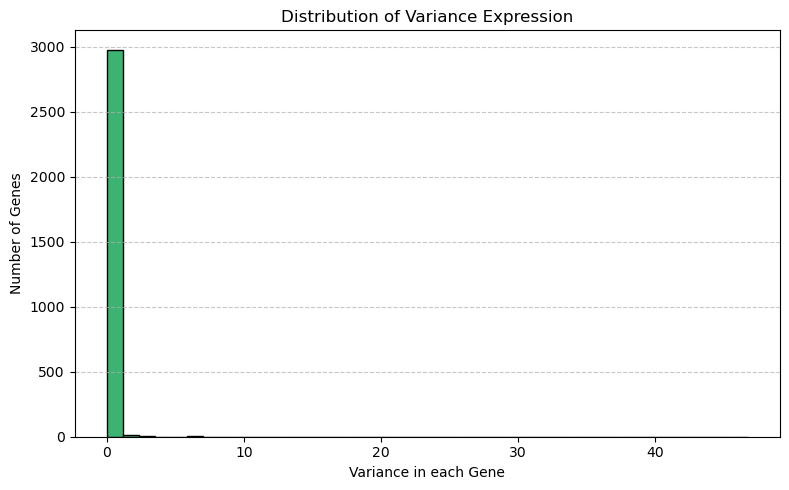

In [77]:
plt.figure(figsize=(8, 5))
plt.hist(variance, bins=40, color='mediumseagreen', edgecolor='black')
plt.xlabel("Variance in each Gene")
plt.ylabel("Number of Genes")
plt.title("Distribution of Variance Expression")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Something else we found important to do was to check how many Hypo and Norm cells we had, to make sure we had enough supports for both cases.

In [79]:

df_DSMCF7.columns = df_DSMCF7.columns.str.strip('"')

normoxia_cells= [col for col in df_DSMCF7.columns if col.endswith('Normoxia')]
hypoxia_cells = [col for col in df_DSMCF7.columns if col.endswith('Hypoxia')]

print(f"Number of Normoxia cells: {len(normoxia_cells)}")
print(f"Number of Hypoxia cells: {len(hypoxia_cells)}")

Number of Normoxia cells: 12705
Number of Hypoxia cells: 8921


To identify what the 10 genes with the highest total expression in normoxia and hypoxia conditions are respectively, we decided to proceed as shown below:

In [81]:
top10_normoxia = df_DSMCF7[normoxia_cells].sum(axis=1).sort_values(ascending=False).head(10)
top10_hypoxia = df_DSMCF7[hypoxia_cells].sum(axis=1).sort_values(ascending=False).head(10)

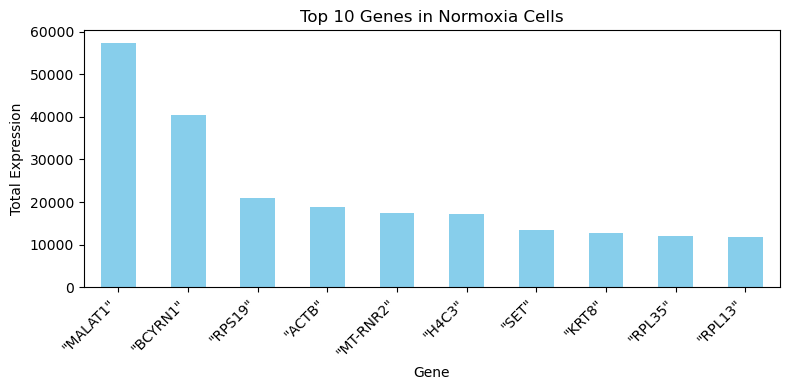

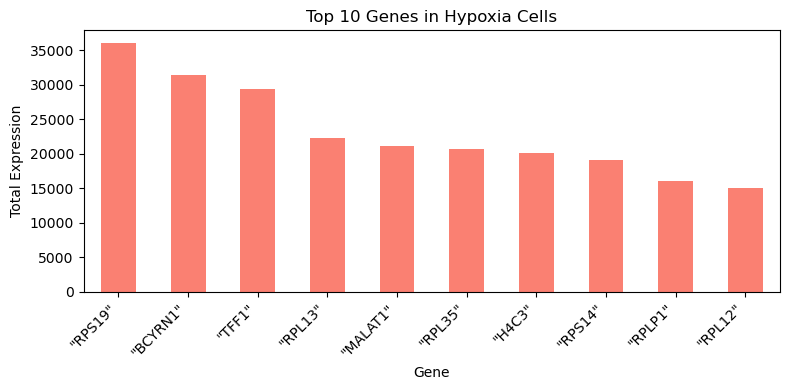

In [82]:
plt.figure(figsize=(8, 4))
top10_normoxia.plot(kind='bar', color='skyblue')
plt.title("Top 10 Genes in Normoxia Cells")
plt.ylabel("Total Expression")
plt.xlabel("Gene")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
top10_hypoxia.plot(kind='bar', color='salmon')
plt.title("Top 10 Genes in Hypoxia Cells")
plt.ylabel("Total Expression")
plt.xlabel("Gene")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

One interesting thing to note is that a few of those highly expressed genes appear in both cases.

Sparsity (proportion of zeros) in df_DSMCF7: 97.53%


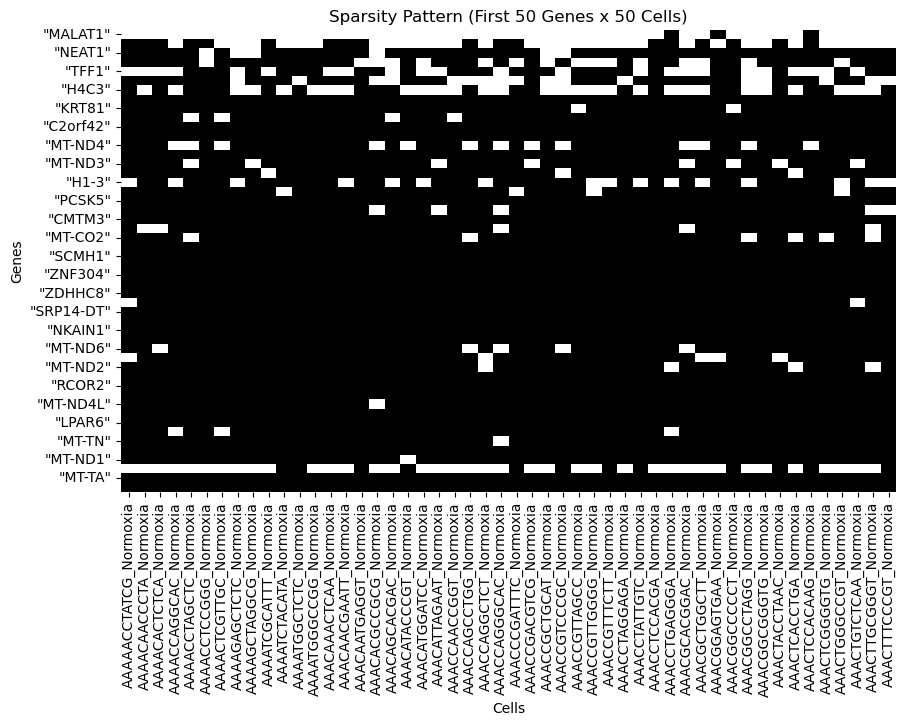

In [84]:
total_elements = df_DSMCF7.size
zero_elements = (df_DSMCF7 == 0).sum().sum()
sparsity = zero_elements / total_elements

print(f"Sparsity (proportion of zeros) in df_DSMCF7: {sparsity:.2%}")

plt.figure(figsize=(10, 6))
sns.heatmap(df_DSMCF7.iloc[:50, :50] == 0, cbar=False, cmap="Greys")
plt.title("Sparsity Pattern (First 50 Genes x 50 Cells)")
plt.xlabel("Cells")
plt.ylabel("Genes")
plt.show()

While not a revolutionary statement by any means, we notice we are dealing with highly sparse data.

As recommended in the report suggestions, we also decided to take a look at the skewness and the kurtosis of the data, as can be seen below:

Mean skewness across genes: 20.47448834691192
Mean kurtosis across genes: 698.6738910236152


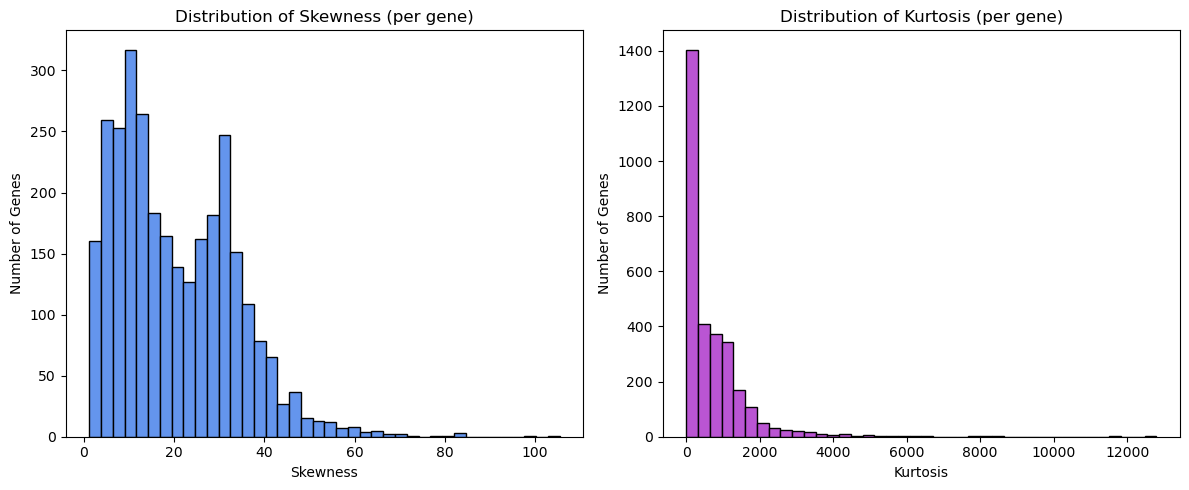

In [87]:



gene_skewness = df_DSMCF7.skew(axis=1)
gene_kurtosis = df_DSMCF7.kurtosis(axis=1)

print("Mean skewness across genes:", gene_skewness.mean())
print("Mean kurtosis across genes:", gene_kurtosis.mean())


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(gene_skewness, bins=40, color='cornflowerblue', edgecolor='black')
plt.title("Distribution of Skewness (per gene)")
plt.xlabel("Skewness")
plt.ylabel("Number of Genes")

plt.subplot(1, 2, 2)
plt.hist(gene_kurtosis, bins=40, color='mediumorchid', edgecolor='black')
plt.title("Distribution of Kurtosis (per gene)")
plt.xlabel("Kurtosis")
plt.ylabel("Number of Genes")

plt.tight_layout()
plt.show()

To check for redundancy and independence, we also decided to take a look at the correlation heatmap of the top 50 most expressed genes.

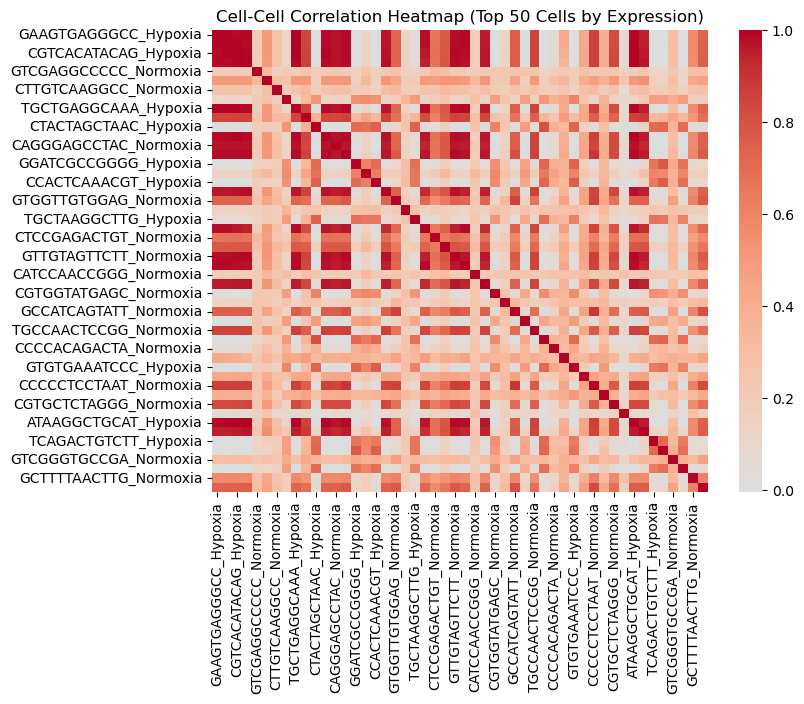

In [89]:

N = 50
total_expression = df_DSMCF7.sum(axis=0)
top_cells = total_expression.sort_values(ascending=False).head(N).index


df_top_cells = df_DSMCF7[top_cells]

# Compute correlation among these cells
corr_top = df_top_cells.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_top, cmap='coolwarm', center=0)
plt.title(f"Cell-Cell Correlation Heatmap (Top {N} Cells by Expression)")
plt.show()

At this point, it is worth noting that even from a purely visual sense, it truly is incredibly interesting to study cells and genes using computational tools. From a practical point of view, however, to get back to the meat of the project, we see that many of the top values are correlated, something to keep in mind when we proceed with our model.

Violin plots below, to explore the density of our data:

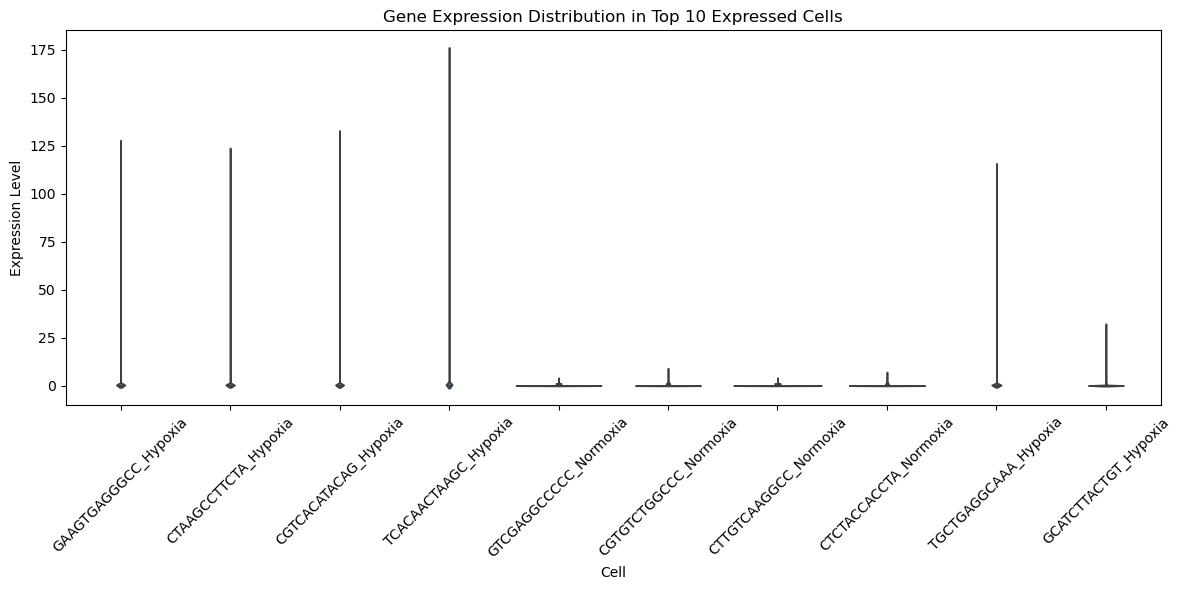

In [92]:
N = 10 
top_cells = df_DSMCF7.sum(axis=0).sort_values(ascending=False).head(N).index
df_top_cells = df_DSMCF7[top_cells]
df_melted = df_top_cells.melt(var_name='Cell', value_name='Expression')

plt.figure(figsize=(12, 6))
sns.violinplot(x='Cell', y='Expression', data=df_melted, inner='quartile')
plt.title(f"Gene Expression Distribution in Top {N} Expressed Cells")
plt.ylabel("Expression Level")
plt.xlabel("Cell")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We confirm something established by the sparsity graph: the vast majority of our gene values are 0.

#### HCC 1806

##### Reading the dataset and showing the first 5 rows

In [96]:
df_DSHCC1806.head()

,"""AAAAAACCCGGC_Normoxia""","""AAAACCGGATGC_Normoxia""","""AAAACGAGCTAG_Normoxia""","""AAAACTTCCCCG_Normoxia""","""AAAAGCCTACCC_Normoxia""","""AAACACAAATCT_Normoxia""","""AAACCAAGCCCA_Normoxia""","""AAACCATGCACT_Normoxia""","""AAACCTCCGGCT_Normoxia""","""AAACGCCGGTCC_Normoxia""",...,"""TTTTCTGATGGT_Hypoxia""","""TTTTGATTCAGA_Hypoxia""","""TTTTGCAACTGA_Hypoxia""","""TTTTGCCGGGCC_Hypoxia""","""TTTTGTTAGCCT_Hypoxia""","""TTTTTACCAATC_Hypoxia""","""TTTTTCCGTGCA_Hypoxia""","""TTTTTGCCTGGG_Hypoxia""","""TTTTTGTAACAG_Hypoxia""","""TTTTTTTGAATC_Hypoxia"""
"""H1-5""",2,2,5,1,0,0,0,0,1,0,...,0,1,0,2,1,0,0,0,3,1
"""MALAT1""",3,3,2,3,12,3,1,2,0,0,...,3,1,1,1,4,0,4,1,3,6
"""MT-RNR2""",0,0,0,0,0,0,0,0,0,1,...,1,2,2,2,0,0,1,0,1,0
"""ARVCF""",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"""BCYRN1""",0,1,1,0,0,1,1,2,0,3,...,1,1,0,1,1,0,0,1,0,0


Here, we want to show the distribution of total different genes present in each cell by filtering the positive values from the dataframe.

"AAAAAACCCGGC_Normoxia"     62
"AAAACCGGATGC_Normoxia"     93
"AAAACGAGCTAG_Normoxia"     51
"AAAACTTCCCCG_Normoxia"     51
"AAAAGCCTACCC_Normoxia"     50
                          ... 
"TTTTTACCAATC_Hypoxia"      43
"TTTTTCCGTGCA_Hypoxia"     106
"TTTTTGCCTGGG_Hypoxia"      83
"TTTTTGTAACAG_Hypoxia"      97
"TTTTTTTGAATC_Hypoxia"      86
Length: 14682, dtype: int64


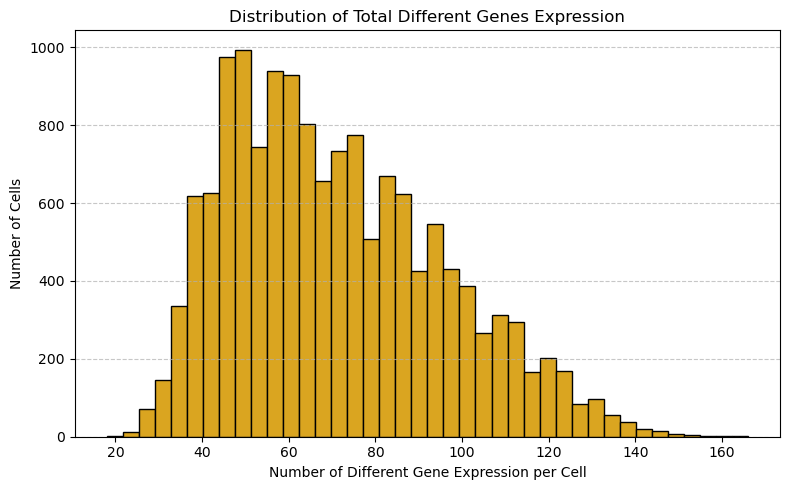

In [98]:
different_genes_per_cell = (df_DSHCC1806 > 0).sum(axis=0)
print(different_genes_per_cell)
plt.figure(figsize=(8, 5))
plt.hist(different_genes_per_cell, bins=40, color='goldenrod', edgecolor='black')
plt.xlabel("Number of Different Gene Expression per Cell")
plt.ylabel("Number of Cells")
plt.title("Distribution of Total Different Genes Expression")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Following, our dataset also needs to be checked for the total number of genes present in each cell, because filtering the cells that have less than 70 genes might help us in reducing our feature number.

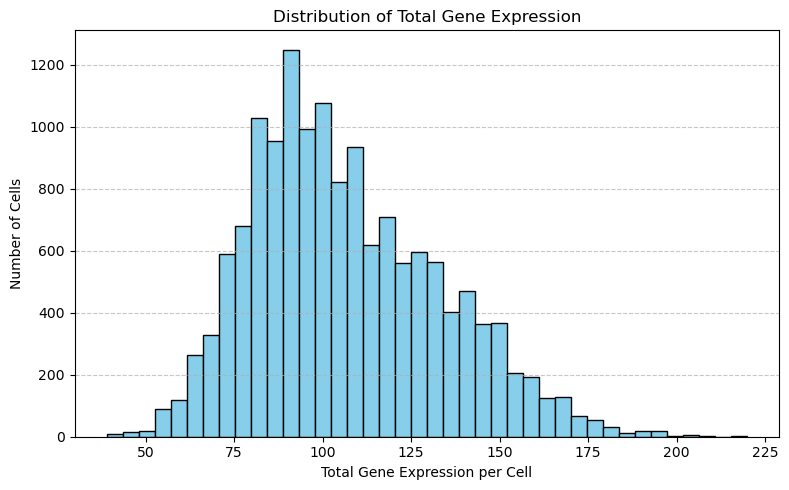

In [100]:
number_of_total_genes = df_DSHCC1806.sum(axis=0)
plt.figure(figsize=(8, 5))
plt.hist(number_of_total_genes, bins=40, color='skyblue', edgecolor='black')
plt.xlabel("Total Gene Expression per Cell")
plt.ylabel("Number of Cells")
plt.title("Distribution of Total Gene Expression")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

At this point, we will also plot the histogram for the percentage of the Mitochondria present in each cell.

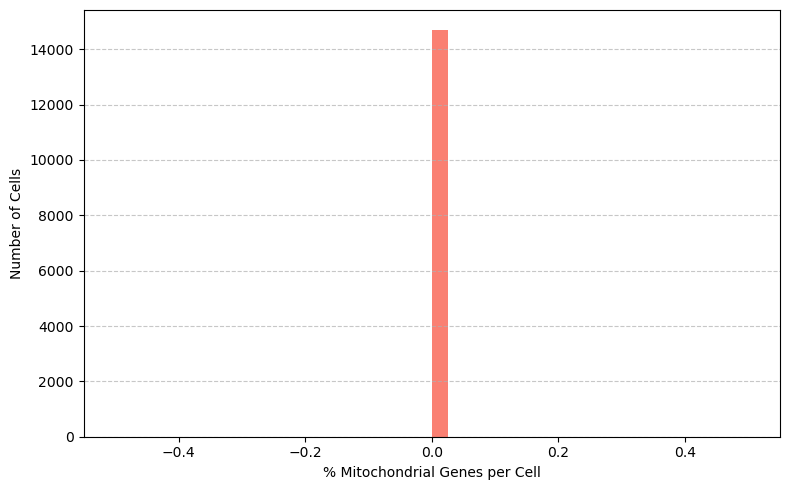

In [102]:
mt_genes = df_DSHCC1806.index.str.startswith("MT-")
pct_mito = df_DSHCC1806[mt_genes].sum(axis=0) / df_DSHCC1806.sum(axis=0)
plt.figure(figsize=(8, 5))
plt.hist(pct_mito, bins=40, color='salmon')
plt.xlabel("% Mitochondrial Genes per Cell")
plt.ylabel("Number of Cells")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

We also want to discover wether there is a linear relationship between the number of different genes and the total number of genes in a cell.

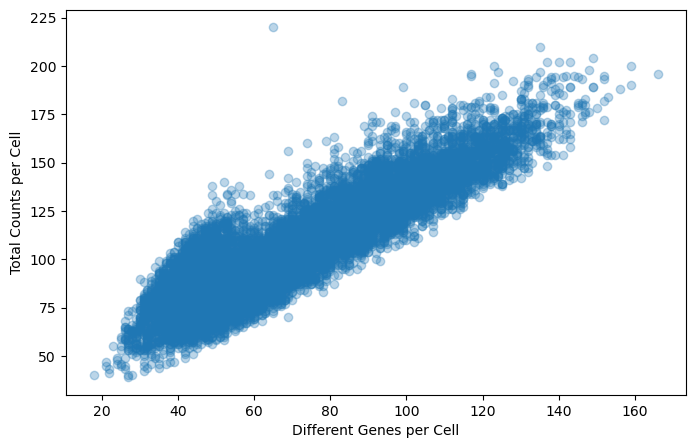

In [104]:
different_genes_per_cell = (df_DSHCC1806 > 0).sum(axis=0)
number_of_total_genes = df_DSHCC1806.sum(axis=0)
plt.figure(figsize=(8, 5))
plt.scatter(different_genes_per_cell, number_of_total_genes, alpha=0.3)
plt.xlabel("Different Genes per Cell")
plt.ylabel("Total Counts per Cell")
plt.show()

In this section, we want to look at the most and the least "popular" genes in our dataset and do some filtering with them.

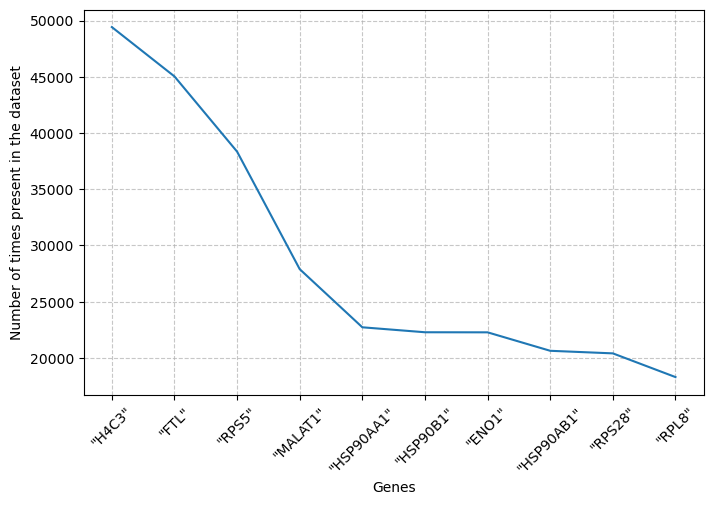

In [106]:
plt.figure(figsize=(8, 5))
most_frequent_genes = df_DSHCC1806.sum(axis=1).sort_values(ascending=False).head(10)
plt.plot(most_frequent_genes)
plt.xticks(rotation=45)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel("Genes")
plt.ylabel("Number of times present in the dataset")
plt.show()

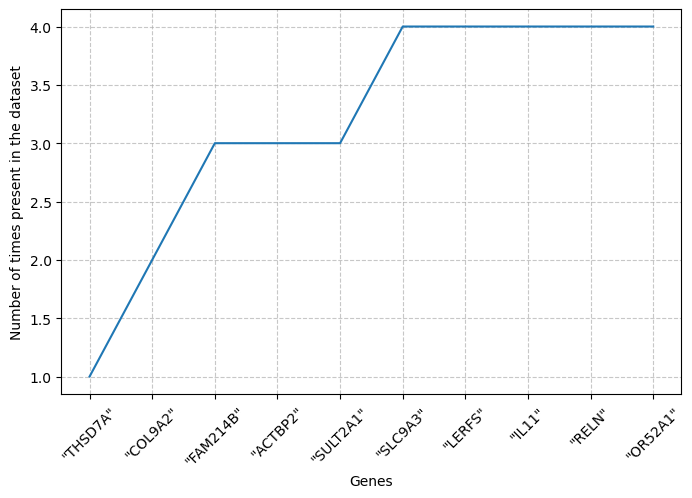

In [107]:
plt.figure(figsize=(8, 5))
most_frequent_genes = df_DSHCC1806.sum(axis=1).sort_values(ascending=True).head(10)
plt.plot(most_frequent_genes)
plt.xticks(rotation=45)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel("Genes")
plt.ylabel("Number of times present in the dataset")
plt.show()

As for the last step, we want to explore the variance of each gene.

In [109]:
variance = df_DSHCC1806.var(axis=1)

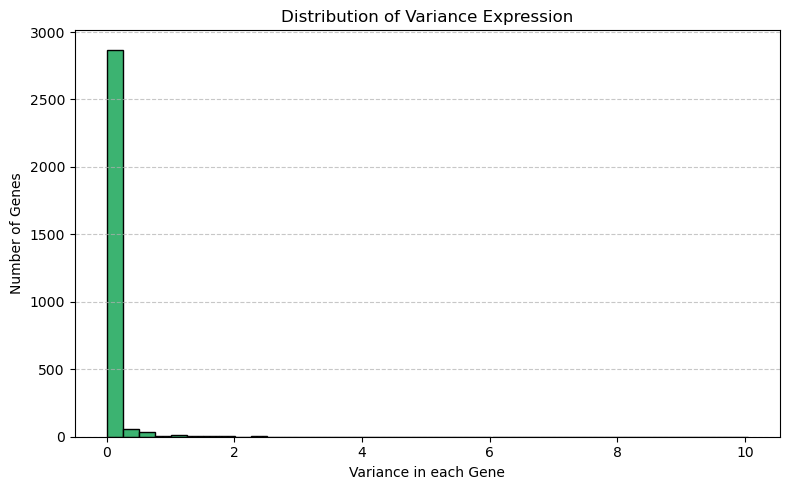

In [110]:
plt.figure(figsize=(8, 5))
plt.hist(variance, bins=40, color='mediumseagreen', edgecolor='black')
plt.xlabel("Variance in each Gene")
plt.ylabel("Number of Genes")
plt.title("Distribution of Variance Expression")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [111]:
df_DSHCC1806.columns = df_DSHCC1806.columns.str.strip('"')

normoxia_cells= [col for col in df_DSHCC1806.columns if col.endswith('Normoxia')]
hypoxia_cells = [col for col in df_DSHCC1806.columns if col.endswith('Hypoxia')]

print(f"Number of Normoxia cells: {len(normoxia_cells)}")
print(f"Number of Hypoxia cells: {len(hypoxia_cells)}")

Number of Normoxia cells: 5783
Number of Hypoxia cells: 8899


In [112]:
top10_normoxia = df_DSHCC1806[normoxia_cells].sum(axis=1).sort_values(ascending=False).head(10)
top10_hypoxia = df_DSHCC1806[hypoxia_cells].sum(axis=1).sort_values(ascending=False).head(10)

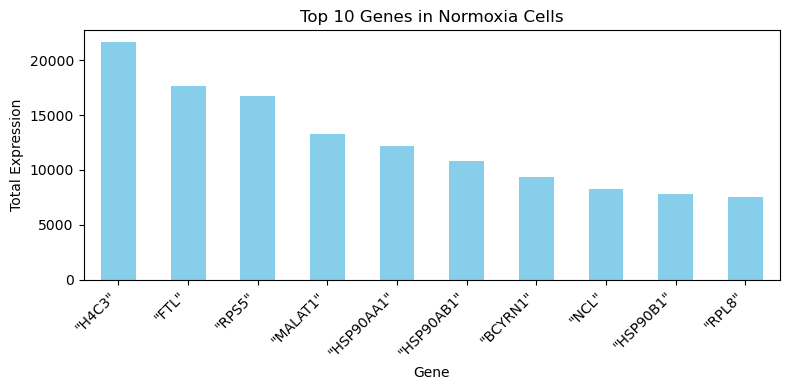

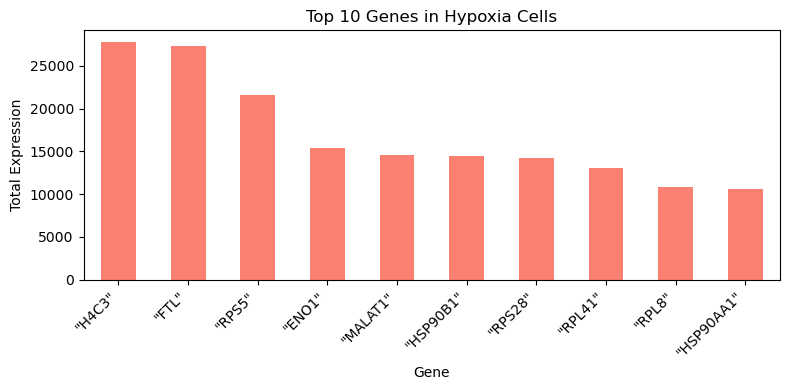

In [113]:
plt.figure(figsize=(8, 4))
top10_normoxia.plot(kind='bar', color='skyblue')
plt.title("Top 10 Genes in Normoxia Cells")
plt.ylabel("Total Expression")
plt.xlabel("Gene")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
top10_hypoxia.plot(kind='bar', color='salmon')
plt.title("Top 10 Genes in Hypoxia Cells")
plt.ylabel("Total Expression")
plt.xlabel("Gene")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Sparsity (proportion of zeros) in df_DSMCF7: 97.53%


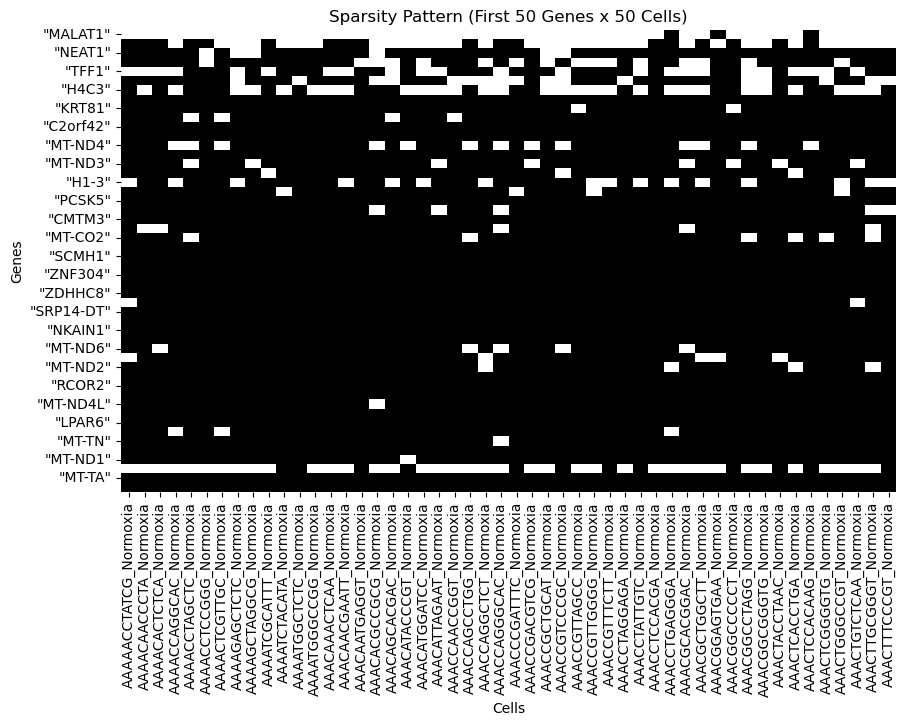

In [114]:

total_elements = df_DSMCF7.size
zero_elements = (df_DSMCF7 == 0).sum().sum()
sparsity = zero_elements / total_elements

print(f"Sparsity (proportion of zeros) in df_DSMCF7: {sparsity:.2%}")


plt.figure(figsize=(10, 6))
sns.heatmap(df_DSMCF7.iloc[:50, :50] == 0, cbar=False, cmap="Greys")
plt.title("Sparsity Pattern (First 50 Genes x 50 Cells)")
plt.xlabel("Cells")
plt.ylabel("Genes")
plt.show()

Mean skewness across genes: 26.31206253822465
Mean kurtosis across genes: 1203.1795018457544


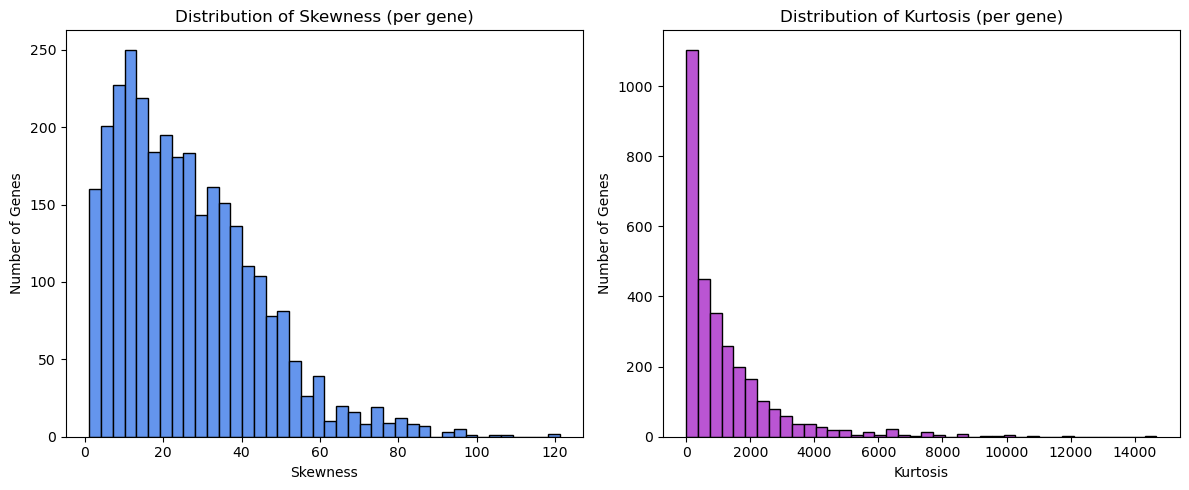

In [115]:


gene_skewness = df_DSHCC1806.skew(axis=1)
gene_kurtosis = df_DSHCC1806.kurtosis(axis=1)

print("Mean skewness across genes:", gene_skewness.mean())
print("Mean kurtosis across genes:", gene_kurtosis.mean())


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(gene_skewness, bins=40, color='cornflowerblue', edgecolor='black')
plt.title("Distribution of Skewness (per gene)")
plt.xlabel("Skewness")
plt.ylabel("Number of Genes")

plt.subplot(1, 2, 2)
plt.hist(gene_kurtosis, bins=40, color='mediumorchid', edgecolor='black')
plt.title("Distribution of Kurtosis (per gene)")
plt.xlabel("Kurtosis")
plt.ylabel("Number of Genes")

plt.tight_layout()
plt.show()

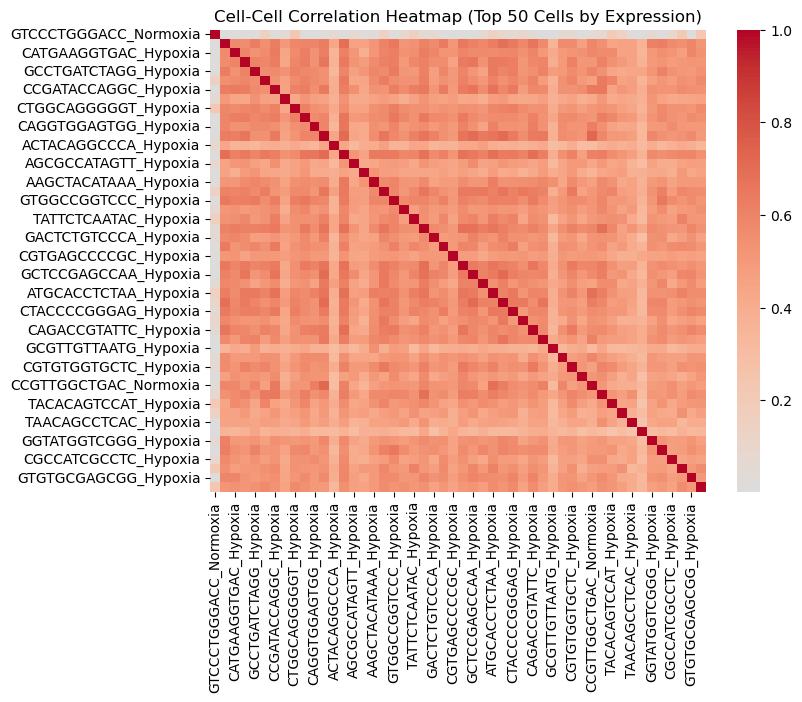

In [116]:
N = 50
total_expression = df_DSHCC1806.sum(axis=0)
top_cells = total_expression.sort_values(ascending=False).head(N).index


df_top_cells = df_DSHCC1806[top_cells]
corr_top = df_top_cells.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_top, cmap='coolwarm', center=0)
plt.title(f"Cell-Cell Correlation Heatmap (Top {N} Cells by Expression)")
plt.show()

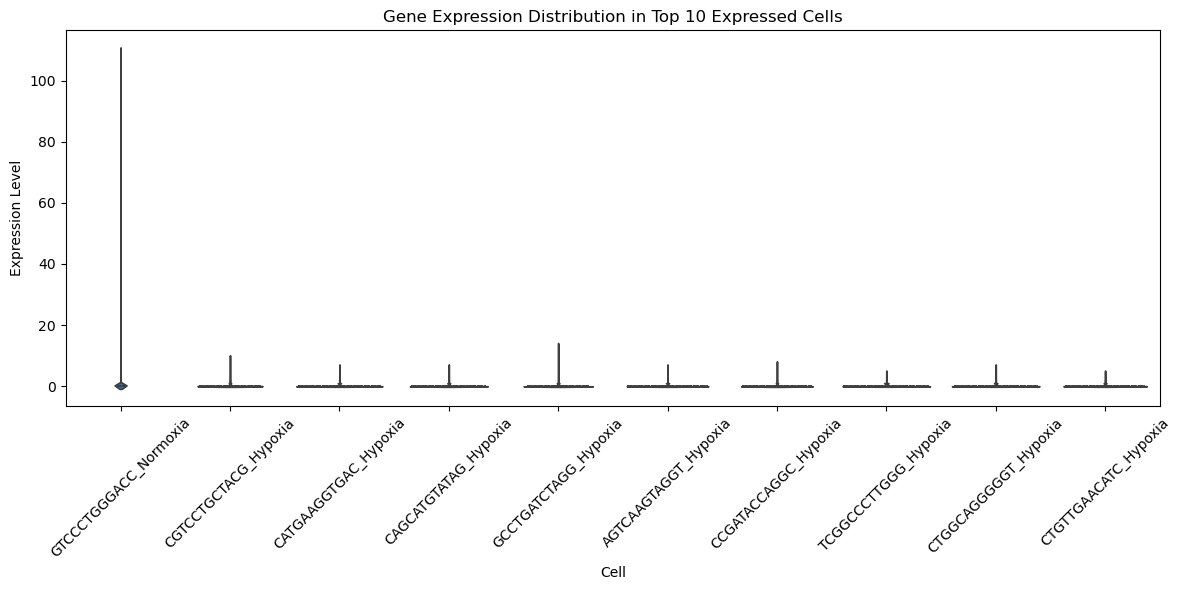

In [117]:
N = 10
top_cells = df_DSHCC1806.sum(axis=0).sort_values(ascending=False).head(N).index
df_top_cells = df_DSHCC1806[top_cells]
df_melted = df_top_cells.melt(var_name='Cell', value_name='Expression')

plt.figure(figsize=(12, 6))
sns.violinplot(x='Cell', y='Expression', data=df_melted, inner='quartile')
plt.title(f"Gene Expression Distribution in Top {N} Expressed Cells")
plt.ylabel("Expression Level")
plt.xlabel("Cell")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

While most of the code and the conclusions are similar to the ones in MCF7 (which is why there aren't many comments), one thing to note is that in HCC1806, in comparison with MCF7, the cells with the most expression are the hypoxic ones.